In [1]:
#load all the necessary libraries
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import math

### Taylor Series in Action

1) Let us start easy. Give me a numpy array from -$\pi$ to +$\pi$. You can use math.pi for $\pi$. Let us called it `xs`

In [2]:
xs = np.linspace(-math.pi, math.pi, 100)

2) Built another numpy array called `ys` which is just the sin of `xs`

In [3]:
ys = np.sin(xs)

3) Plot `xs` vs `ys`

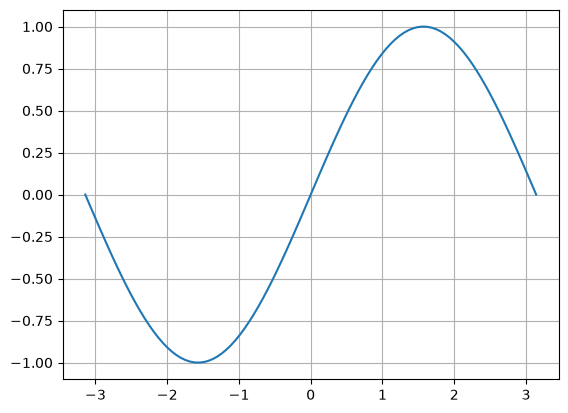

In [4]:
plt.plot(xs,ys)
plt.grid()

4) Plot
$\begin{align}
g(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!}
\end{align}$

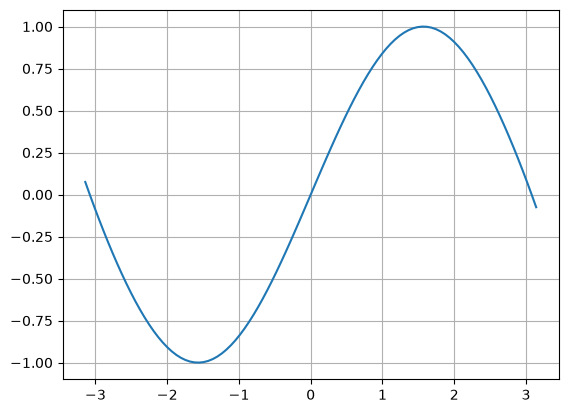

In [5]:
fac = math.factorial

def g(x):
  return x - x**3/fac(3) + x**5/fac(5) - x**7/fac(7)

plt.plot(xs,g(xs))
plt.grid()

5) Plot g(x) and sin(x) on the same axis

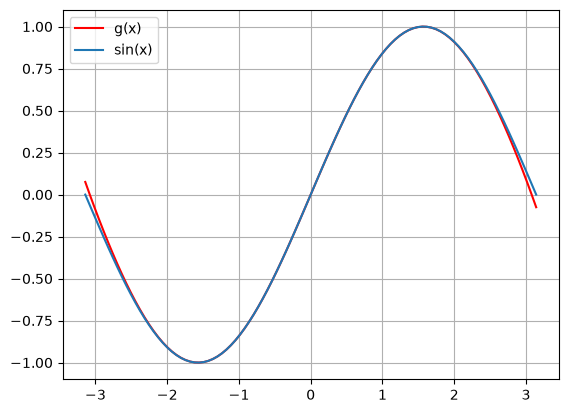

In [6]:
plt.plot(xs,g(xs), 'r', label = 'g(x)')
plt.plot(xs,ys, label = 'sin(x)')
plt.grid()
plt.legend()

6) Plot the $\sin$ function and the taylor series approximation( 1 term ) on the same axis

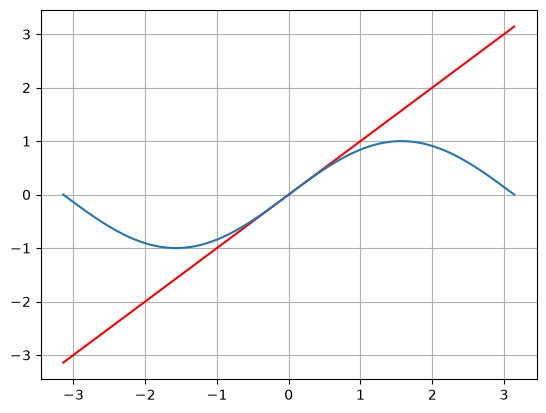

In [7]:
def g1(x):
  return x

plt.plot(xs,g1(xs), 'r')
plt.plot(xs,ys)
plt.grid()

7) Plot the $\sin$ function and the taylor series approximation( 2 terms ) on the same axis

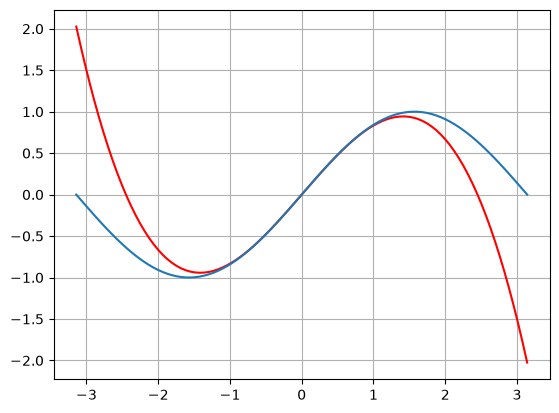

In [8]:
def g2(x):
  return x - x**3/fac(3)

plt.plot(xs,g2(xs), 'r')
plt.plot(xs,ys)
plt.grid()

8) Plot the $\sin$ function and the taylor series approximation( 3 term ) on the same axis

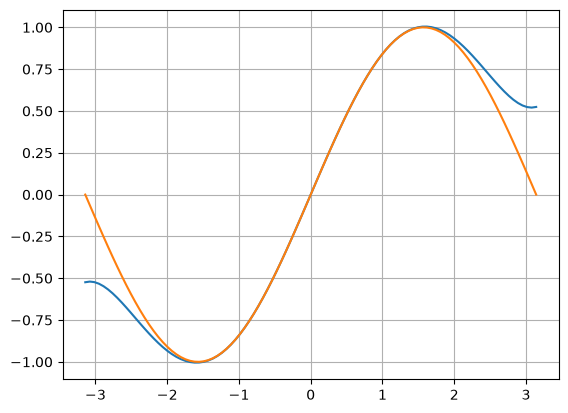

In [9]:
def g3(x):
  return x - x**3/fac(3) + x**5/fac(5)

plt.plot(xs,g3(xs))
plt.plot(xs,ys)
plt.grid()

9) Plot the $\sin$ function and the taylor series approximations(1,2,3,4 terms ) on the same axis. You can see that we get more and more accurate as we add more terms.

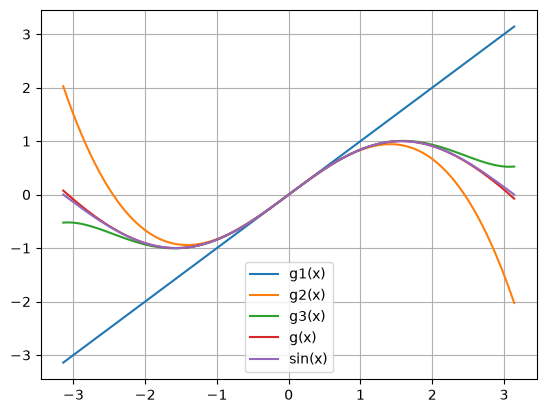

In [10]:
plt.plot(xs,g1(xs), label = 'g1(x)')
plt.plot(xs,g2(xs), label = 'g2(x)')
plt.plot(xs,g3(xs), label = 'g3(x)')
plt.plot(xs,g(xs), label = 'g(x)')
plt.plot(xs,ys, label = 'sin(x)')
plt.grid()
plt.legend()

10) Verify the above example that the error is bounded by $R$.

In [11]:
print(np.sin(0.1))
print(0.1-0.1**3/fac(3)+0.1**5/fac(5)-0.1**7/fac(7))
print(np.sin(0.1) - (0.1-0.1**3/fac(3)+0.1**5/fac(5)-0.1**7/fac(7)))

0.09983341664682815
0.09983341664682541
2.7478019859472624e-15


11) If we use only the two terms in the approximation, what is the bound on the uncertainty/error for approximating $\sin(0.5)$. Verify this numerically as well.

$$
  |R_3(0.5)| \leq \frac{0.5^4}{4!} \approx 0.00260417
$$

In [12]:
x = 0.5
approx = x - x**3 / math.factorial(3)
true_val = np.sin(x)

error = abs(true_val - approx)
bound = x**4 / math.factorial(4)

print(f"Approximation: {approx:.12f}")
print(f"Actual value:  {true_val:.12f}")
print(f"Actual error:  {error:.12f}")
print(f"Error bound:   {bound:.12f}")
print("Within bound:", error <= bound)

Approximation: 0.479166666667
Actual value:  0.479425538604
Actual error:  0.000258871938
Error bound:   0.002604166667
Within bound: True


12) If we want to approximate $\sin(0.5)$ that is accurate up to $10^{-7}$. How many terms do we need?

$$ \text{error} = [-1, 1] \times \frac{0.5^{(k+1)}}{k+1!} \le 10^{-7} $$

$$ 2 \times \frac{0.5^{k+1}}{(k+1)!} \le 10^{-7} $$

We can now write a loop to find the smallest k that satisfies this condition.

In [13]:
for i in range(20):
  error = 2 * (0.5**(i+1)) / fac(i+1)
  if error < 1e-7:
    print(i)
    break

8
